In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh

import finite_difference_quantum as fin

In [10]:
L = 1.0


def isw_energy_theory(n, L=L):
    return (n * np.pi / L) ** 2 / 2.0


def ground_state_energy(N, order):
    V = lambda x: 0.0 * x
    H = fin.hamiltonian(V, 0.0, L, N, order=order)
    vals, _ = eigsh(H, k=1, which="SM", tol=1e-12, maxiter=50000)
    vals = np.sort(vals)
    return float(vals[0])

In [11]:
N_values = np.arange(40, 601, 20)
E_ref = isw_energy_theory(1, L=L)

errors_2nd = []
errors_4th = []

for N in N_values:
    E2 = ground_state_energy(N, order=2)
    E4 = ground_state_energy(N, order=4)
    errors_2nd.append(abs(E2 - E_ref) / abs(E_ref))
    errors_4th.append(abs(E4 - E_ref) / abs(E_ref))

errors_2nd = np.array(errors_2nd)
errors_4th = np.array(errors_4th)

Fitted slope (2nd order): -1.99
Fitted slope (4th order): -4.26


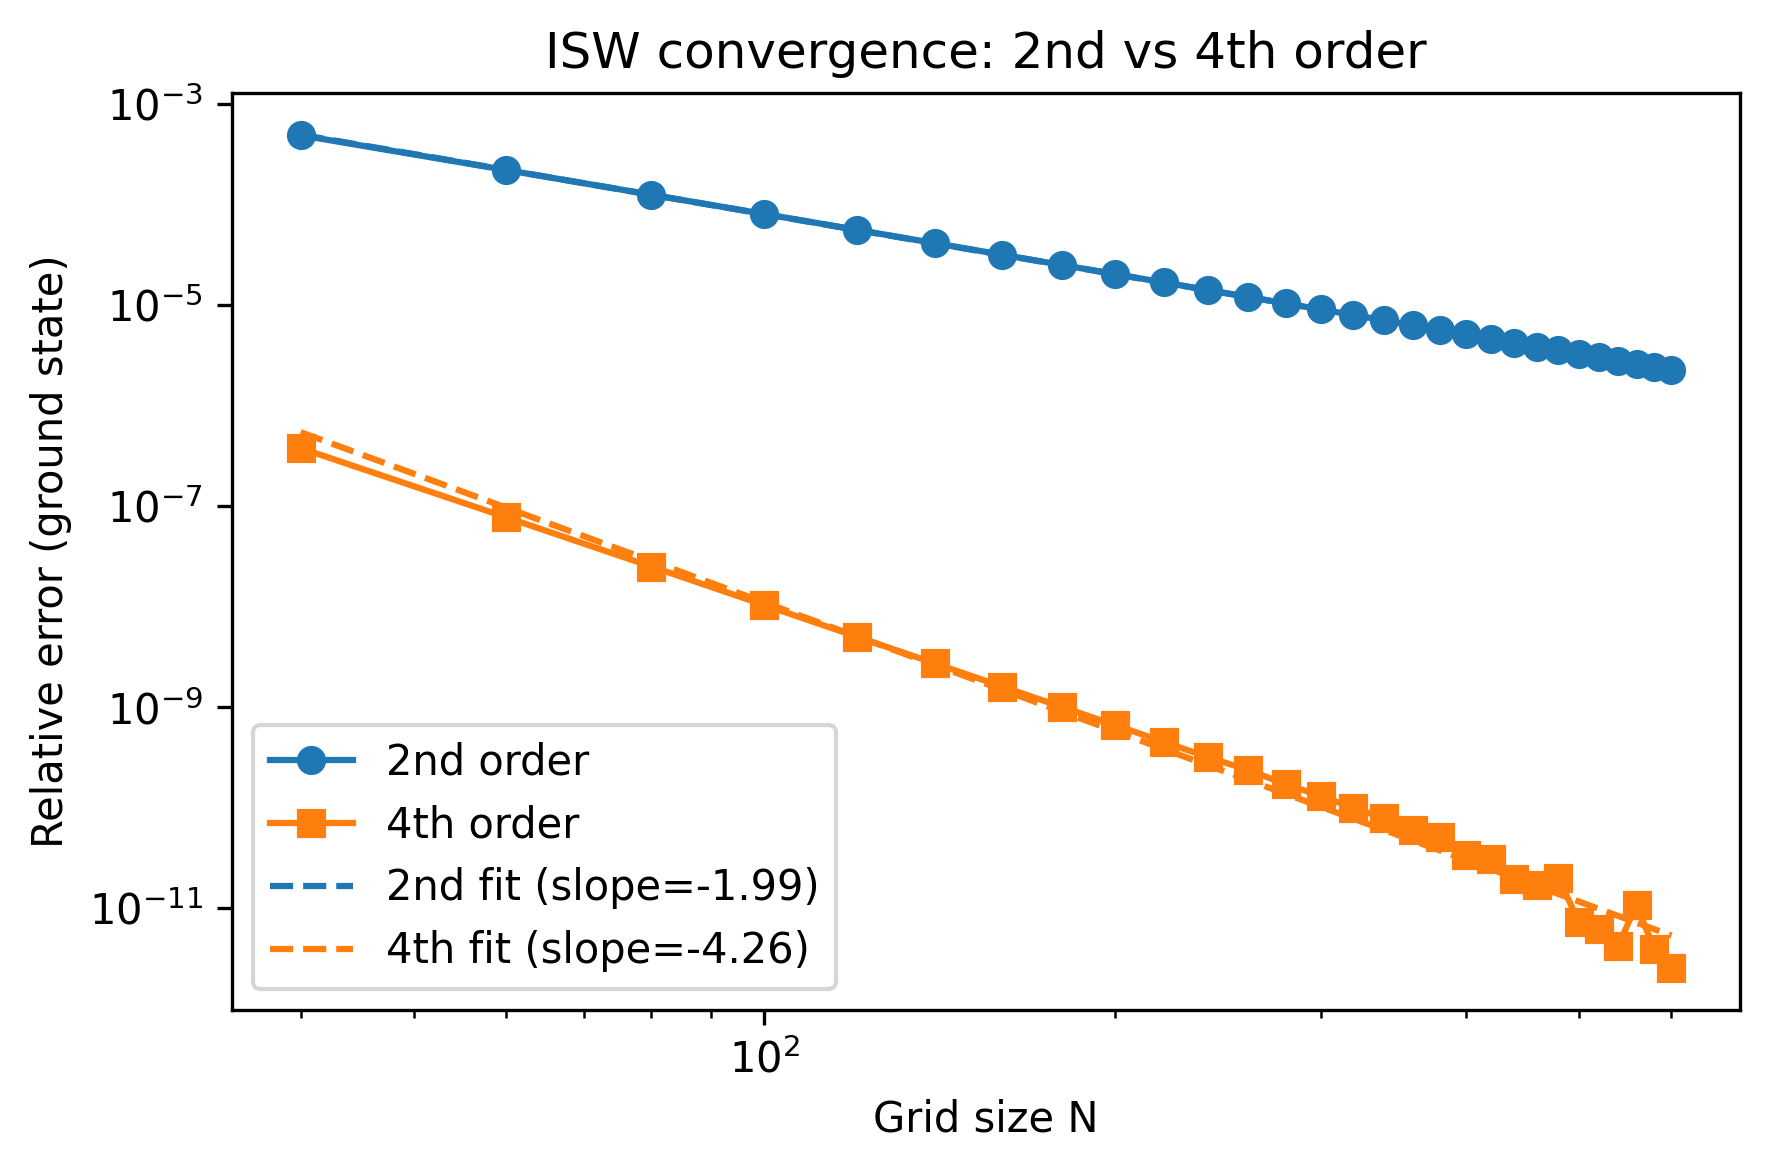

In [12]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

ax.loglog(N_values, errors_2nd, "o-", label="2nd order")
ax.loglog(N_values, errors_4th, "s-", label="4th order")

# Fit slopes on log-log scale
logN = np.log(N_values)
loge2 = np.log(errors_2nd)
loge4 = np.log(errors_4th)

slope2, intercept2 = np.polyfit(logN, loge2, 1)
slope4, intercept4 = np.polyfit(logN, loge4, 1)

print(f"Fitted slope (2nd order): {slope2:.2f}")
print(f"Fitted slope (4th order): {slope4:.2f}")

N_fit = np.linspace(N_values.min(), N_values.max(), 200)
ax.loglog(N_fit, np.exp(intercept2) * N_fit ** slope2, "--", color="C0",
          label=f"2nd fit (slope={slope2:.2f})")
ax.loglog(N_fit, np.exp(intercept4) * N_fit ** slope4, "--", color="C1",
          label=f"4th fit (slope={slope4:.2f})")

ax.set_xlabel("Grid size N")
ax.set_ylabel("Relative error (ground state)")
ax.set_title("ISW convergence: 2nd vs 4th order")
ax.legend()

plt.tight_layout()
plt.show()